In [1]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
import seaborn as sns

In [2]:
df = pd.read_csv('../datasets/credit_risk_dataset.csv')
df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4


In [3]:
df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length              895
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3116
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

In [4]:
df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,32581.000000,3.258100e+04,31686.000000,32581.000000,29465.000000,32581.000000,32581.000000,32581.000000
mean,27.734600,6.607485e+04,4.789686,9589.371106,11.011695,0.218164,0.170203,5.804211
std,6.348078,6.198312e+04,4.142630,6322.086646,3.240459,0.413006,0.106782,4.055001
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.850000e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.500000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,7.920000e+04,7.000000,12200.000000,13.470000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,123.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


* person_age with 144 is uncanny - hence outlier

In [9]:
df_pivot = pd.pivot_table(data=df, index='person_emp_length', values='loan_status', aggfunc='count').sort_values(by='person_emp_length', ascending=False)
df_pivot

,loan_status
person_emp_length,
123.0,2
41.0,1
38.0,1
34.0,1
31.0,4
30.0,2
29.0,1
28.0,3
27.0,5


In [10]:
df[df['person_emp_length'] > 47]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
0,22,59000,RENT,123.0,PERSONAL,D,35000,16.02,1,0.59,Y,3
210,21,192000,MORTGAGE,123.0,VENTURE,A,20000,6.54,0,0.10,N,4


<Axes: xlabel='person_emp_length'>

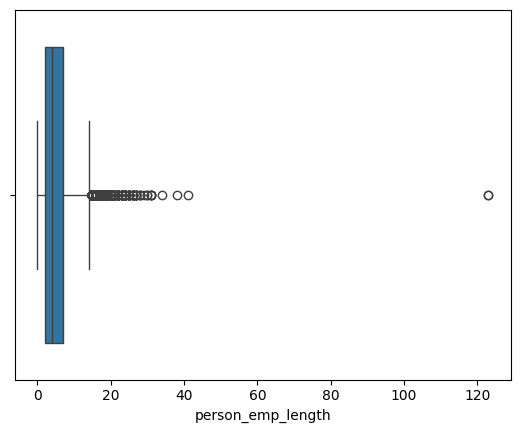

In [11]:
sns.boxplot(x=df['person_emp_length'])

In [14]:
new_df = df[df['person_emp_length']<47]
new_df

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
1,21,9600,OWN,5.0,EDUCATION,B,1000,11.14,0,0.10,N,2
2,25,9600,MORTGAGE,1.0,MEDICAL,C,5500,12.87,1,0.57,N,3
3,23,65500,RENT,4.0,MEDICAL,C,35000,15.23,1,0.53,N,2
4,24,54400,RENT,8.0,MEDICAL,C,35000,14.27,1,0.55,Y,4
5,21,9900,OWN,2.0,VENTURE,A,2500,7.14,1,0.25,N,2
...,...,...,...,...,...,...,...,...,...,...,...,...
32576,57,53000,MORTGAGE,1.0,PERSONAL,C,5800,13.16,0,0.11,N,30
32577,54,120000,MORTGAGE,4.0,PERSONAL,A,17625,7.49,0,0.15,N,19
32578,65,76000,RENT,3.0,HOMEIMPROVEMENT,B,35000,10.99,1,0.46,N,28
32579,56,150000,MORTGAGE,5.0,PERSONAL,B,15000,11.48,0,0.10,N,26


In [15]:
new_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31684.000000,3.168400e+04,31684.000000,31684.000000,28636.000000,31684.000000,31684.000000,31684.000000
mean,27.747696,6.668817e+04,4.782224,9660.211779,11.039850,0.215408,0.169601,5.809462
std,6.360289,6.242527e+04,4.034888,6334.560789,3.229241,0.411112,0.106273,4.060952
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.939600e+04,2.000000,5000.000000,7.900000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.480000,0.000000,0.230000,8.000000
max,144.000000,6.000000e+06,41.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


Text(0.5, 0, 'Person Age')

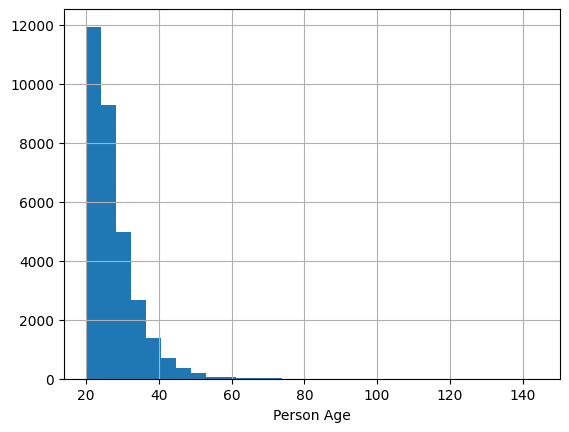

In [16]:
new_df['person_age'].hist(bins=30)
plt.xlabel('Person Age')

<Axes: xlabel='person_age'>

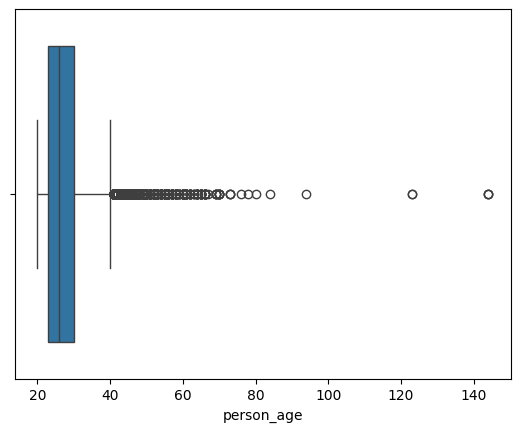

In [17]:
sns.boxplot(x=new_df['person_age'])

In [18]:
new_df[new_df['person_age']>80]

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_grade,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length
81,144,250000,RENT,4.0,VENTURE,C,4800,13.57,0,0.02,N,3
183,144,200000,MORTGAGE,4.0,EDUCATION,B,6000,11.86,0,0.03,N,2
575,123,80004,RENT,2.0,EDUCATION,B,20400,10.25,0,0.25,N,3
747,123,78000,RENT,7.0,VENTURE,B,20000,NaN,0,0.26,N,4
32297,144,6000000,MORTGAGE,12.0,PERSONAL,C,5000,12.73,0,0.00,N,25
32416,94,24000,RENT,1.0,MEDICAL,C,6500,NaN,0,0.27,N,27
32506,84,94800,MORTGAGE,2.0,PERSONAL,A,10000,7.51,0,0.11,N,24


In [34]:
new_df.groupby('person_age')['loan_status'].count().reset_index().sort_values(by='person_age', ascending=False)

,person_age,loan_status
57,144,3
56,123,2
55,94,1
54,84,1
53,80,1
52,78,1
51,76,1
50,73,3
49,70,6
48,69,5


In [38]:
age_pivot = pd.pivot_table(data=new_df, index='person_age',columns='loan_status', values='person_emp_length', aggfunc='count').sort_values(by='person_age', ascending=False)
age_pivot

loan_status,0,1
person_age,,
144,3.0,NaN
123,2.0,NaN
94,1.0,NaN
84,1.0,NaN
80,1.0,NaN
78,1.0,NaN
76,1.0,NaN
73,3.0,NaN
70,4.0,2.0


In [39]:
new_df = new_df[new_df['person_age']<=70]

In [40]:
new_df.shape

(31671, 12)

In [41]:
new_df.isna().sum()

person_age                       0
person_income                    0
person_home_ownership            0
person_emp_length                0
loan_intent                      0
loan_grade                       0
loan_amnt                        0
loan_int_rate                 3045
loan_status                      0
loan_percent_income              0
cb_person_default_on_file        0
cb_person_cred_hist_length       0
dtype: int64

Text(0.5, 0, 'Loan Interest Rate')

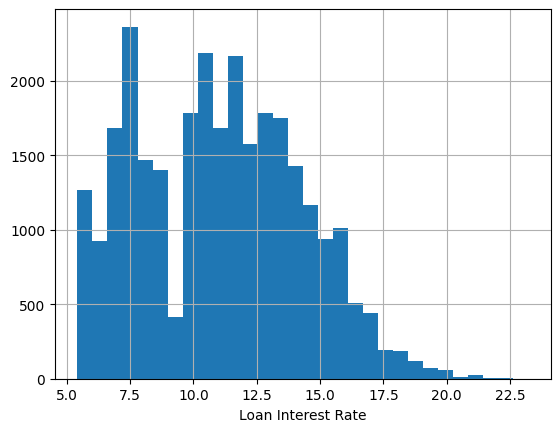

In [42]:
new_df['loan_int_rate'].hist(bins=30)
plt.xlabel('Loan Interest Rate')

In [44]:
loan_rate_median = new_df['loan_int_rate'].median()
new_df.loc[:,'loan_int_rate'] = new_df['loan_int_rate'].fillna(new_df['loan_int_rate'].median())

In [45]:
new_df.isna().sum()

person_age                    0
person_income                 0
person_home_ownership         0
person_emp_length             0
loan_intent                   0
loan_grade                    0
loan_amnt                     0
loan_int_rate                 0
loan_status                   0
loan_percent_income           0
cb_person_default_on_file     0
cb_person_cred_hist_length    0
dtype: int64

In [46]:
new_df.describe()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_cred_hist_length
count,31671.000000,3.167100e+04,31671.000000,31671.000000,31671.000000,31671.000000,31671.000000,31671.000000
mean,27.717754,6.649231e+04,4.780714,9660.637492,11.035256,0.215497,0.169621,5.804395
std,6.159859,5.277413e+04,4.028718,6334.716643,3.070364,0.411173,0.106275,4.048776
min,20.000000,4.000000e+03,0.000000,500.000000,5.420000,0.000000,0.000000,2.000000
25%,23.000000,3.936600e+04,2.000000,5000.000000,8.490000,0.000000,0.090000,3.000000
50%,26.000000,5.600000e+04,4.000000,8000.000000,10.990000,0.000000,0.150000,4.000000
75%,30.000000,8.000000e+04,7.000000,12500.000000,13.160000,0.000000,0.230000,8.000000
max,70.000000,2.039784e+06,38.000000,35000.000000,23.220000,1.000000,0.830000,30.000000


In [47]:
new_df.select_dtypes(include=['object'])

,person_home_ownership,loan_intent,loan_grade,cb_person_default_on_file
1,OWN,EDUCATION,B,N
2,MORTGAGE,MEDICAL,C,N
3,RENT,MEDICAL,C,N
4,RENT,MEDICAL,C,Y
5,OWN,VENTURE,A,N
...,...,...,...,...
32576,MORTGAGE,PERSONAL,C,N
32577,MORTGAGE,PERSONAL,A,N
32578,RENT,HOMEIMPROVEMENT,B,N
32579,MORTGAGE,PERSONAL,B,N


In [48]:
new_df.drop(columns=['loan_grade'],inplace=True)

C:\Users\Ann\AppData\Local\Temp\ipykernel_11476\1386766149.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df.drop(columns=['loan_grade'],inplace=True)


In [102]:
new_df.to_csv('../datasets/credit_risk_cleaned.csv', index=False)

In [49]:
new_df.select_dtypes(include=['object'])

,person_home_ownership,loan_intent,cb_person_default_on_file
1,OWN,EDUCATION,N
2,MORTGAGE,MEDICAL,N
3,RENT,MEDICAL,N
4,RENT,MEDICAL,Y
5,OWN,VENTURE,N
...,...,...,...
32576,MORTGAGE,PERSONAL,N
32577,MORTGAGE,PERSONAL,N
32578,RENT,HOMEIMPROVEMENT,N
32579,MORTGAGE,PERSONAL,N


In [50]:
new_df['person_home_ownership'].value_counts()

person_home_ownership
RENT        16066
MORTGAGE    13088
OWN          2410
OTHER         107
Name: count, dtype: int64

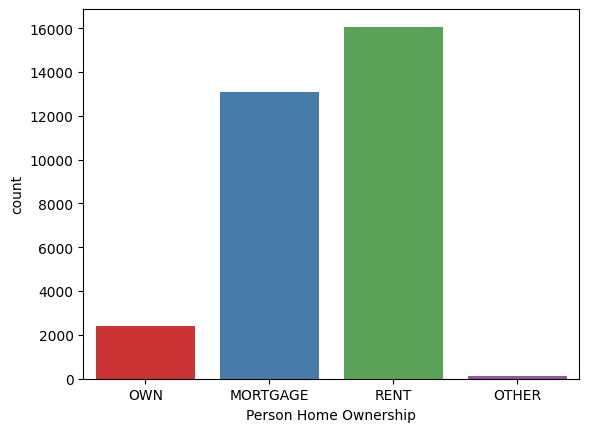

In [54]:
sns.countplot(new_df,x='person_home_ownership',hue='person_home_ownership',palette='Set1')
plt.xlabel('Person Home Ownership');


In [62]:
person_home = pd.get_dummies(new_df['person_home_ownership'], drop_first=True).astype('int')
person_home

,OTHER,OWN,RENT
1,0,1,0
2,0,0,0
3,0,0,1
4,0,0,1
5,0,1,0
...,...,...,...
32576,0,0,0
32577,0,0,0
32578,0,0,1
32579,0,0,0


In [57]:
new_df.loc[:,'cb_person_codes'] = new_df['cb_person_default_on_file'].map({'Y':0,'N':1}) # type: ignore
new_df.head()

,person_age,person_income,person_home_ownership,person_emp_length,loan_intent,loan_amnt,loan_int_rate,loan_status,loan_percent_income,cb_person_default_on_file,cb_person_cred_hist_length,cb_person_codes
1,21,9600,OWN,5.0,EDUCATION,1000,11.14,0,0.10,N,2,1
2,25,9600,MORTGAGE,1.0,MEDICAL,5500,12.87,1,0.57,N,3,1
3,23,65500,RENT,4.0,MEDICAL,35000,15.23,1,0.53,N,2,1
4,24,54400,RENT,8.0,MEDICAL,35000,14.27,1,0.55,Y,4,0
5,21,9900,OWN,2.0,VENTURE,2500,7.14,1,0.25,N,2,1


In [58]:
new_df['loan_intent'].value_counts()

loan_intent
EDUCATION            6288
MEDICAL              5891
VENTURE              5553
PERSONAL             5365
DEBTCONSOLIDATION    5064
HOMEIMPROVEMENT      3510
Name: count, dtype: int64

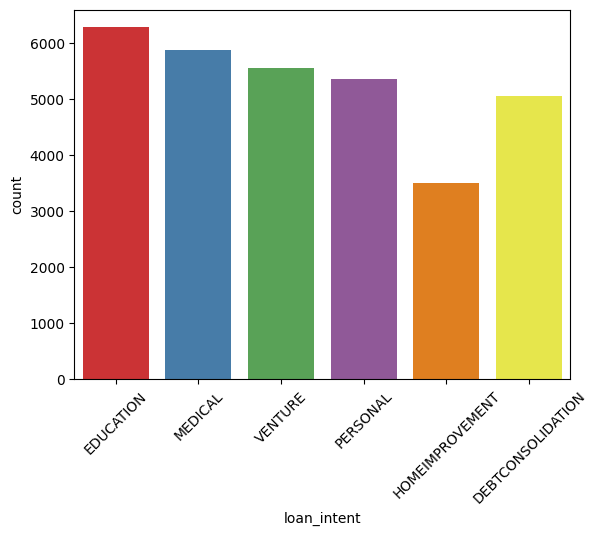

In [60]:
sns.countplot(new_df,x='loan_intent',hue='loan_intent',palette='Set1')
plt.xticks(rotation=45)
plt.show()

In [63]:
loan_intent=pd.get_dummies(new_df['loan_intent'], drop_first=True).astype('int')
loan_intent

,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
1,1,0,0,0,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,1,0,0
5,0,0,0,0,1
...,...,...,...,...,...
32576,0,0,0,1,0
32577,0,0,0,1,0
32578,0,1,0,0,0
32579,0,0,0,1,0


In [ ]:
new_df_ = new_df.drop(columns=['loan_intent','person_home_ownership','cb_person_default_on_file'])

In [76]:
new_df_.drop(columns='loan_status', inplace=True)

In [77]:
new_df_.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_codes
1,21,9600,5.0,1000,11.14,0.10,2,1
2,25,9600,1.0,5500,12.87,0.57,3,1
3,23,65500,4.0,35000,15.23,0.53,2,1
4,24,54400,8.0,35000,14.27,0.55,4,0
5,21,9900,2.0,2500,7.14,0.25,2,1


In [83]:
from sklearn.preprocessing import StandardScaler    
scaler=StandardScaler()

new_df_scaled = pd.DataFrame(scaler.fit_transform(new_df_),columns=new_df_.columns)
new_df_scaled.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_codes
0,-1.090587,-1.078051,0.054432,-1.367192,0.034115,-0.655113,-0.939656,0.464870
1,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664,0.464870
2,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656,0.464870
3,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671,-2.151139
4,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656,0.464870


In [84]:
new_df_oth=pd.merge(new_df_scaled,person_home,left_index=True,right_index=True)
new_df_oth=pd.merge(new_df_oth,loan_intent,left_index=True,right_index=True)
new_df_oth.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_codes,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE
1,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664,0.464870,0,1,0,1,0,0,0,0
2,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656,0.464870,0,0,0,0,0,1,0,0
3,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671,-2.151139,0,0,1,0,0,1,0,0
4,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656,0.464870,0,0,1,0,0,1,0,0
5,-0.278867,0.201005,0.799097,4.000141,0.451010,2.638293,-0.692664,0.464870,0,1,0,0,0,0,0,1


In [96]:
new_df_oth = pd.concat([new_df_oth, new_df['loan_status']], axis=1)
new_df_oth.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_codes,OTHER,OWN,RENT,EDUCATION,HOMEIMPROVEMENT,MEDICAL,PERSONAL,VENTURE,loan_status
1,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664,0.464870,0.0,1.0,0.0,1.0,0.0,0.0,0.0,0.0,0
2,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656,0.464870,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1
3,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671,-2.151139,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
4,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656,0.464870,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1
5,-0.278867,0.201005,0.799097,4.000141,0.451010,2.638293,-0.692664,0.464870,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,1


In [97]:
new_df_oth['loan_status'].value_counts()

loan_status
0    24846
1     6825
Name: count, dtype: int64

In [98]:
from imblearn.over_sampling import SMOTE
smote=SMOTE(random_state=42)

In [99]:
X = new_df_oth.drop(columns='loan_status')
y = new_df_oth['loan_status']

In [101]:
new_df_oth.isna().sum()

person_age                    879
person_income                 879
person_emp_length             879
loan_amnt                     879
loan_int_rate                 879
loan_percent_income           879
cb_person_cred_hist_length    879
cb_person_codes               879
OTHER                         879
OWN                           879
RENT                          879
EDUCATION                     879
HOMEIMPROVEMENT               879
MEDICAL                       879
PERSONAL                      879
VENTURE                       879
loan_status                     0
dtype: int64

In [100]:
X_smote,y_smote=smote.fit_resample(X,y) # pyright: ignore[reportAssignmentType]
X_smote.shape, y_smote.shape

ValueError: Input X contains NaN.
SMOTE does not accept missing values encoded as NaN natively. For supervised learning, you might want to consider sklearn.ensemble.HistGradientBoostingClassifier and Regressor which accept missing values encoded as NaNs natively. Alternatively, it is possible to preprocess the data, for instance by using an imputer transformer in a pipeline or drop samples with missing values. See https://scikit-learn.org/stable/modules/impute.html You can find a list of all estimators that handle NaN values at the following page: https://scikit-learn.org/stable/modules/impute.html#estimators-that-handle-nan-values

In [89]:
y_smote.value_counts()

loan_status
0    24846
1    24846
Name: count, dtype: int64

In [93]:
X_smote.head()

,person_age,person_income,person_emp_length,loan_amnt,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,cb_person_codes
0,-1.090587,-1.078051,0.054432,-1.367192,0.034115,-0.655113,-0.939656,0.464870
1,-0.441211,-1.078051,-0.938456,-0.656810,0.597575,3.767461,-0.692664,0.464870
2,-0.765899,-0.018803,-0.193790,4.000141,1.366226,3.391072,-0.939656,0.464870
3,-0.603555,-0.229137,0.799097,4.000141,1.053554,3.579267,-0.445671,-2.151139
4,-1.090587,-1.072366,-0.690234,-1.130398,-1.268682,0.756347,-0.939656,0.464870
